# 04 — Train a Tiny LLM (end to end, on CPU)

**Companion to [Chapter 06](../06-pretraining.md).**

This notebook trains a real language model from random weights to working text
generation in about a minute on a laptop CPU.

The corpus is generated from a small grammar, so the model has learnable
structure and you can *see* it being learned. Everything here — the loss, the
loop, the schedule, the clipping — is exactly what a billion-dollar training run
does, just smaller.

In [1]:
import math, time
import torch
import torch.nn as nn

torch.manual_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 1. A corpus with learnable structure

Generated from a template grammar. The model must learn the sentence pattern,
the vocabulary, and which words fit which slot.

In [2]:
import random
random.seed(0)

SUBJECTS = ["the cat", "the dog", "a bird", "the child", "my friend", "the robot"]
VERBS    = ["sits on", "jumps over", "looks at", "runs past", "sleeps near"]
OBJECTS  = ["the mat", "the fence", "a chair", "the table", "the garden"]
ENDINGS  = ["quietly.", "every morning.", "in the sun.", "without a sound.", "again."]

sentences = [f"{random.choice(SUBJECTS)} {random.choice(VERBS)} "
             f"{random.choice(OBJECTS)} {random.choice(ENDINGS)}"
             for _ in range(1200)]
text = " ".join(sentences)

print(f"corpus: {len(text):,} characters")
print("\nsample:")
print(text[:220])

corpus: 48,249 characters

sample:
the child runs past the mat in the sun. my friend runs past the table in the sun. the child looks at the garden every morning. my friend jumps over a chair every morning. the cat sleeps near a chair again. the robot slee


## 2. Character-level tokenizer

Character-level keeps this notebook dependency-free and makes the output easy to
read. The mechanics are identical with BPE — only the vocabulary changes.

In [3]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

print(f"vocabulary : {vocab_size} characters")
print(f"chars      : {''.join(chars)!r}")
print(f"tokenized  : {len(data):,} tokens")
print(f"round-trip : {decode(encode('the cat sits'))!r}")

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"\ntrain {len(train_data):,} tokens | val {len(val_data):,} tokens")

vocabulary : 26 characters
chars      : ' .abcdefghijklmnopqrstuvwy'
tokenized  : 48,249 tokens
round-trip : 'the cat sits'

train 43,424 tokens | val 4,825 tokens


## 3. Batching

Inputs and targets are the same slice offset by one position.

In [4]:
CONTEXT = 64
BATCH = 32

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - CONTEXT - 1, (BATCH,))
    x = torch.stack([d[i:i + CONTEXT] for i in ix])
    y = torch.stack([d[i + 1:i + CONTEXT + 1] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch("train")
print("inputs :", tuple(xb.shape))
print("targets:", tuple(yb.shape))
print()
print("input  :", repr(decode(xb[0][:40].tolist())))
print("target :", repr(decode(yb[0][:40].tolist())))
print("\nThe target is the input shifted left by one character.")

inputs : (32, 64)
targets: (32, 64)

input  : 'ning. the child sleeps near the mat with'
target : 'ing. the child sleeps near the mat witho'

The target is the input shifted left by one character.


## 4. The model

Same architecture as notebook 03, sized down so it trains in seconds.

In [5]:
import torch
import torch.nn as nn

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift


class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x ** 3)))


class FeedForward(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim), GELU(), nn.Linear(4 * emb_dim, emb_dim))

    def forward(self, x):
        return self.layers(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout=0.0, num_heads=12, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out, self.num_heads = d_out, num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(
            torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, n, _ = x.shape
        q = self.W_query(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.W_key(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.W_value(x).view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        scores = q @ k.transpose(2, 3) / k.shape[-1] ** 0.5
        scores = scores.masked_fill(self.mask.bool()[:n, :n], -torch.inf)
        w = self.dropout(torch.softmax(scores, dim=-1))
        ctx = (w @ v).transpose(1, 2).contiguous().view(b, n, self.d_out)
        return self.out_proj(ctx)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            cfg["emb_dim"], cfg["emb_dim"], cfg["context_length"],
            cfg["drop_rate"], cfg["n_heads"], cfg["qkv_bias"])
        self.ff = FeedForward(cfg["emb_dim"])
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        x = x + self.drop(self.att(self.norm1(x)))    # attention sublayer + residual
        x = x + self.drop(self.ff(self.norm2(x)))     # feed-forward sublayer + residual
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, idx):
        _, n = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(n, device=idx.device))
        x = self.blocks(self.drop(x))
        return self.out_head(self.final_norm(x))

CFG = {
    "vocab_size": vocab_size,
    "context_length": CONTEXT,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

torch.manual_seed(123)
model = GPTModel(CFG).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}  ({n_params * 4 / 1e6:.2f} MB at fp32)")

parameters: 806,656  (3.23 MB at fp32)


## 5. The sanity check that saves hours

At initialization the model knows nothing, so it should spread probability
uniformly across the vocabulary:

```
initial loss ~= ln(vocab_size)
```

**Always check this on step 0.** If it matches, your model, data pipeline and
loss function are wired correctly.

In [6]:
import torch.nn.functional as F

@torch.no_grad()
def estimate_loss(model, iters=20):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(iters)
        for k in range(iters):
            x, y = get_batch(split)
            logits = model(x)
            losses[k] = F.cross_entropy(logits.flatten(0, 1), y.flatten()).item()
        out[split] = losses.mean().item()
    model.train()
    return out


initial = estimate_loss(model)
expected = math.log(vocab_size)
print(f"expected at init : {expected:.4f}   (ln of vocab size {vocab_size})")
print(f"actual           : {initial['train']:.4f}")
print(f"difference       : {abs(initial['train'] - expected):.4f}")
print("\nMatch -> the pipeline is correct. Now we can train.")

expected at init : 3.2581   (ln of vocab size 26)
actual           : 3.3999
difference       : 0.1418

Match -> the pipeline is correct. Now we can train.


## 6. The training loop

Every element of a real pretraining run is here: warmup, cosine decay,
gradient clipping, periodic evaluation.

In [7]:
MAX_STEPS = 600
WARMUP = 60
BASE_LR = 3e-3
MIN_LR = 3e-4

def lr_at(step):
    if step < WARMUP:                                     # linear warmup
        return BASE_LR * (step + 1) / WARMUP
    progress = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return MIN_LR + 0.5 * (BASE_LR - MIN_LR) * (1 + math.cos(math.pi * progress))


optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=0.1)
history = {"step": [], "train": [], "val": []}

start_time = time.time()
model.train()

for step in range(MAX_STEPS):
    for g in optimizer.param_groups:                      # apply the schedule
        g["lr"] = lr_at(step)

    xb, yb = get_batch("train")

    optimizer.zero_grad()                                 # 1. clear old gradients
    logits = model(xb)                                    # 2. forward
    loss = F.cross_entropy(logits.flatten(0, 1), yb.flatten())   # 3. loss
    loss.backward()                                       # 4. gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)      # 4b. clip
    optimizer.step()                                      # 5. update

    if step % 100 == 0 or step == MAX_STEPS - 1:
        losses = estimate_loss(model, iters=10)
        history["step"].append(step)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        print(f"step {step:4d} | lr {lr_at(step):.2e} | "
              f"train {losses['train']:.4f} | val {losses['val']:.4f} | "
              f"ppl {math.exp(losses['val']):6.2f}")

print(f"\ntrained in {time.time() - start_time:.1f}s")
print(f"loss went from {initial['train']:.3f} -> {history['train'][-1]:.3f}")
print(f"perplexity     {math.exp(initial['train']):.1f} -> {math.exp(history['val'][-1]):.1f}")

step    0 | lr 5.00e-05 | train 3.3716 | val 3.3678 | ppl  29.01


step  100 | lr 2.96e-03 | train 0.4088 | val 0.4218 | ppl   1.52


step  200 | lr 2.58e-03 | train 0.2175 | val 0.2195 | ppl   1.25


step  300 | lr 1.88e-03 | train 0.2063 | val 0.2100 | ppl   1.23


step  400 | lr 1.12e-03 | train 0.2023 | val 0.2070 | ppl   1.23


step  500 | lr 5.22e-04 | train 0.2034 | val 0.2068 | ppl   1.23


step  599 | lr 3.00e-04 | train 0.1995 | val 0.2012 | ppl   1.22

trained in 76.3s
loss went from 3.400 -> 0.199
perplexity     30.0 -> 1.2


## 7. The loss curve

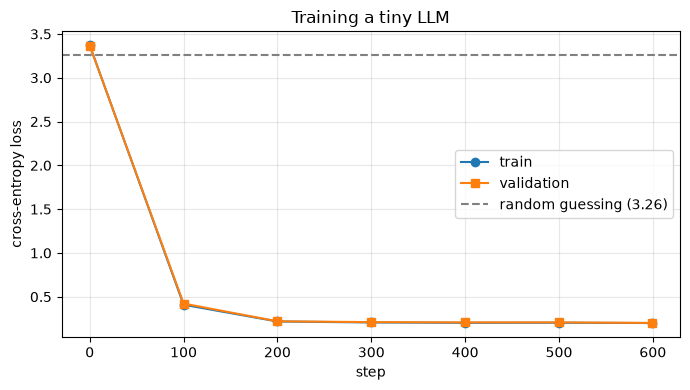


Healthy: both curves fall together with a small gap.
If validation turned UPWARD while train kept falling, that is overfitting.


In [8]:
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["step"], history["train"], marker="o", label="train")
    ax.plot(history["step"], history["val"], marker="s", label="validation")
    ax.axhline(expected, ls="--", c="gray", label=f"random guessing ({expected:.2f})")
    ax.set_xlabel("step"); ax.set_ylabel("cross-entropy loss")
    ax.set_title("Training a tiny LLM"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not installed - printing instead\n")
    for s, t, v in zip(history["step"], history["train"], history["val"]):
        bar = "#" * int(t * 12)
        print(f"step {s:4d}  train {t:.3f}  val {v:.3f}  {bar}")

print("\nHealthy: both curves fall together with a small gap.")
print("If validation turned UPWARD while train kept falling, that is overfitting.")

## 8. Generate text

The model started as noise. Look at what it produces now.

In [9]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=200, temperature=0.8, top_k=None):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        logits = model(idx[:, -CONTEXT:])[:, -1, :]
        if top_k is not None:
            kth = torch.topk(logits, top_k).values[..., -1, None]
            logits = torch.where(logits < kth, torch.tensor(float("-inf")), logits)
        probs = torch.softmax(logits / temperature, dim=-1)
        idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
    return decode(idx[0].tolist())


print("=" * 70)
print(generate(model, "the cat ", max_new_tokens=200, temperature=0.8))
print("=" * 70)

the cat looks at the garden in the sun. the cat runs past the mat again. my friend jumps over the garden every morning. my friend jumps over the garden in the sun. a bird jumps over the mat again. the dog sit


The model has learned the grammar: subjects, verbs, objects, endings, spelling,
and where periods go. From random weights, in under a minute, from nothing but
next-character prediction.

Scale this up — more data, more parameters, more compute — and you get GPT.
That is genuinely the whole story.

## 9. Temperature, visible

In [10]:
for temp in [0.2, 0.6, 1.0, 1.5]:
    print(f"--- temperature {temp} " + "-" * 45)
    print(generate(model, "the dog ", max_new_tokens=110, temperature=temp))
    print()
print("Low  -> repetitive and safe.  High -> creative, then incoherent.")

--- temperature 0.2 ---------------------------------------------


the dog sits on the table quietly. the cat sleeps near the fence quietly. the cat sits on the fence in the sun. the ca

--- temperature 0.6 ---------------------------------------------


the dog runs past the mat every morning. the child runs past the garden in the sun. the cat jumps over the fence in th

--- temperature 1.0 ---------------------------------------------


the dog looks at the mat every morning. the cat looks at the mat again. the child looks at a chair in the sun. the cat

--- temperature 1.5 ---------------------------------------------


the dog jhe sumps over the garrden again. a bird sleeps near the table quietly. the very morning. the cat sleeps near 

Low  -> repetitive and safe.  High -> creative, then incoherent.


## 10. Save and resume

Save the optimizer too — AdamW's momentum is real progress you would otherwise discard.

In [11]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": CFG,
    "stoi": stoi,
}, "tiny_llm.pth")

ckpt = torch.load("tiny_llm.pth", weights_only=False)
restored = GPTModel(ckpt["config"]).to(device)
restored.load_state_dict(ckpt["model_state_dict"])
print("saved and reloaded successfully")
print("checkpoint keys:", list(ckpt.keys()))

saved and reloaded successfully
checkpoint keys: ['model_state_dict', 'optimizer_state_dict', 'config', 'stoi']


## Exercises

1. **Cause overfitting deliberately.** Cut the corpus to 50 sentences and train 2000 steps. Watch validation loss turn upward.
2. **Break it.** Set `BASE_LR = 1.0` and watch divergence. Then remove `clip_grad_norm_` and see if it gets worse.
3. **Scale it.** Double `n_layers` and `emb_dim`. Does the loss go lower? How much slower is it?
4. **Remove the causal mask** in `MultiHeadAttention` and retrain. The loss will collapse — explain why that is cheating, not learning.

**Next:** [05 — Decoding Strategies](05_decoding_strategies.ipynb)